# 01 · Building a ReAct Agent inside LangGraph

> Workshop module. So far we built **workflows** - graphs where *we* hard-wired the path
> (prompt chaining, routing, parallelization). Now we build an **agent** - a graph where the
> **LLM decides the path** at runtime.

We will build a **ReAct agent** from scratch, one piece at a time, so nothing is magic:

1. The idea: **Reason -> Act -> Observe**, looping.
2. The state: **`MessagesState`** (and why it's different from the TypedDict state we wrote for workflows).
3. Node 1: the **LLM node** (Reason).
4. Node 2: the **tool node** (Act) - explained line by line.
5. The router that creates the **loop**.
6. Wire it up and **run** it.
7. Then: *you don't have to write the tool node* - meet **`ToolNode`**.
8. And the whole thing in one line - **`create_agent`**.

## 0 · Setup

In [19]:
import os
# --- Load API keys from the project .env, no matter how/where Jupyter was started ---
_ENV_PATH = "/Users/datasense/Desktop/langgrapgh-agent/.env"
for _line in open(_ENV_PATH):
    _line = _line.strip()
    if _line and not _line.startswith("#") and "=" in _line:
        _k, _v = _line.split("=", 1)
        os.environ[_k.strip()] = _v.strip().strip('"').strip("'")
print("Loaded keys:", [k for k in ("OPENAI_API_KEY", "TAVILY_API_KEY", "SERPAPI_API_KEY") if os.getenv(k)])
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY missing from .env"

from IPython.display import Image, display

def show(graph):
    "Render a compiled LangGraph as an inline mermaid PNG (ASCII fallback if offline)."
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        print(graph.get_graph().draw_ascii())

def render_mermaid(mermaid_text):
    "Render any mermaid diagram string as an inline PNG."
    from langchain_core.runnables.graph_mermaid import draw_mermaid_png
    display(Image(draw_mermaid_png(mermaid_text)))

from langchain.chat_models import init_chat_model
llm = init_chat_model("openai:gpt-4o-mini", temperature=0)
print("LLM ready")

Loaded keys: ['OPENAI_API_KEY', 'TAVILY_API_KEY', 'SERPAPI_API_KEY']
LLM ready


## 1 · What is a ReAct agent?

**ReAct = Reason + Act.** Instead of a fixed pipeline, the model runs in a loop:

- **Reason**  - the LLM thinks: *"do I need a tool? which one?"*
- **Act**     - if yes, we run that tool
- **Observe** - the tool's result is fed back to the LLM
- ...repeat until the LLM has the final answer.

As a graph it is just **two nodes** and a **loop** - here it is as a mermaid diagram:

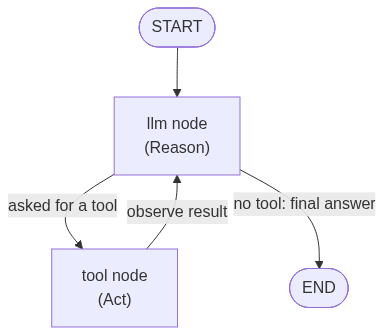

In [20]:
render_mermaid('''
graph TD
    S([START]) --> L["llm node<br/>(Reason)"]
    L -->|asked for a tool| T["tool node<br/>(Act)"]
    T -->|observe result| L
    L -->|no tool: final answer| E([END])
''')

The back-edge `tool node -> llm node` is what makes it an *agent* and not a workflow:
the model gets to look at the tool result and decide what to do next.

![agent](images/agent.png)

## 2 · The tools, and how the LLM "asks" for one

First, some tools. A tool is a normal Python function with the `@tool` decorator. The **docstring
matters** - the model reads it to decide when to use the tool.

In [21]:
from langchain.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two numbers a and b."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers a and b."""
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """Divide a by b."""
    return a / b

tools = [add, multiply, divide]
print("tool name:", add.name)
print("tool desc:", add.description)
print("tool args:", add.args)

tool name: add
tool desc: Add two numbers a and b.
tool args: {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


Now we **bind** the tools to the model with `bind_tools`. This tells the model *"these tools exist"*.

Important: the model does **not** run the tool. It returns a **request** to call it - a `tool_calls`
list. Running it is *our* job (that's the tool node, next). Let's see that request directly:

In [22]:
llm_with_tools = llm.bind_tools(tools)

from langchain.messages import HumanMessage
ai_msg = llm_with_tools.invoke([HumanMessage("What is 3 plus 4?")])

print("content    :", repr(ai_msg.content), "  <- empty: the model didn't answer, it wants a tool")
print("tool_calls :", ai_msg.tool_calls)

content    : ''   <- empty: the model didn't answer, it wants a tool
tool_calls : [{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_rvN3xouORkiB2QUK2joKlfDY', 'type': 'tool_call'}]


Read that `tool_calls` entry: `{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_...'}`.

- `name`  - which tool the model wants
- `args`  - the arguments it chose
- `id`    - a unique id; we must send the result back tagged with this same id

That is the whole "Act" decision. Our agent just needs to *execute* it and feed the result back.

## 3 · The state - meet `MessagesState`

For workflows we wrote our own state, e.g. `class State(TypedDict): topic: str; joke: str`. Each node
filled in fields.

An agent is different: its "state" is simply the **growing conversation** - a list of messages
(human, AI, tool results). LangGraph ships a ready-made state for exactly this: **`MessagesState`**.

It is literally just this:

```python
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
```

Two things to unpack:

- **`messages`** - one field, a list of messages.
- **`add_messages`** - the **reducer**. Remember from workflows: a reducer says *how* a node's output
  is merged into state. `add_messages` means **append** (not overwrite). So when a node returns
  `{"messages": [some_msg]}`, that message is *added* to the conversation instead of replacing it.

Let's prove the reducer appends:

In [23]:
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage, AIMessage

conversation = [HumanMessage("hi")]
print("START -", len(conversation), "message in the list:")
print(conversation, "\n")

# a node returns a NEW message; add_messages merges it into the existing list
conversation = add_messages(conversation, [AIMessage("hello there!")])
print("AFTER add_messages -", len(conversation), "messages in the list:")
print(conversation, "\n")

print("same list, readable:")
for m in conversation:
    print(f"  {m.type:>6}: {m.content}")
print("\n-> the list GREW from 1 to 2: add_messages APPENDED the AI message, it did NOT overwrite the human one.")

START - 1 message in the list:
[HumanMessage(content='hi', additional_kwargs={}, response_metadata={})] 

AFTER add_messages - 2 messages in the list:
[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='8fe7760a-7913-4f5b-b546-14331ee57522'), AIMessage(content='hello there!', additional_kwargs={}, response_metadata={}, id='8ba642cc-210d-435b-bce0-0c9d40a1e6e7', tool_calls=[], invalid_tool_calls=[])] 

same list, readable:
   human: hi
      ai: hello there!

-> the list GREW from 1 to 2: add_messages APPENDED the AI message, it did NOT overwrite the human one.


The message **types** you'll see flowing through the state:

| type | class | who made it |
|---|---|---|
| `human`  | `HumanMessage`  | the user |
| `ai`     | `AIMessage`     | the model (may carry `.tool_calls`) |
| `tool`   | `ToolMessage`   | the result of running a tool |
| `system` | `SystemMessage` | our instructions to the model |

So our whole agent state is: *a list of these, that keeps growing.*

## 4 · Node 1 - the LLM node (Reason)

A node is just a function: `state in -> dict out`. The LLM node:

1. takes the current `messages`,
2. prepends a `SystemMessage` (the agent's instructions),
3. calls the tool-bound model,
4. returns the model's reply under `"messages"` - which the `add_messages` reducer appends.

In [ ]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage

SYSTEM = "You are a helpful assistant that does arithmetic on a set of inputs."

def llm_node(state: MessagesState):
    """Reason: let the model think and (maybe) request a tool."""
    response = llm_with_tools.invoke([SystemMessage(SYSTEM)] + state["messages"])
    return {"messages": [response]}   # appended to the conversation by add_messages

## 5 · Node 2 - the tool node (Act), line by line

This is the heart of the agent. When the model asks for tools, this node runs them. Let's read it
slowly - every line has a job:

```python
def tool_node(state):
    tools_by_name = {t.name: t for t in tools}   # (a) name -> tool, so we can look it up
    last_message = state["messages"][-1]          # (b) the AI msg that asked for tools
    results = []
    for call in last_message.tool_calls:          # (c) the model can ask for SEVERAL tools at once
        tool = tools_by_name[call["name"]]        # (d) find the tool it named
        observation = tool.invoke(call["args"])   # (e) actually run it with the model's args
        results.append(ToolMessage(               # (f) wrap the result as a ToolMessage...
            content=str(observation),
            tool_call_id=call["id"],              # (g) ...tagged with the SAME id, so the model
        ))                                        #     knows which request this answers
    return {"messages": results}                  # (h) append all results to the conversation
```

The key subtlety is **(g)**: `tool_call_id` links each result back to the exact request. Without it
the model can't match answers to questions. Here's the real node:

In [26]:
from langchain.messages import ToolMessage

tools_by_name = {t.name: t for t in tools}

def tool_node(state: MessagesState):
    """Act: run every tool the model asked for, return the results."""
    last_message = state["messages"][-1]
    results = []
    for call in last_message.tool_calls:
        tool = tools_by_name[call["name"]]
        observation = tool.invoke(call["args"])
        results.append(ToolMessage(content=str(observation), tool_call_id=call["id"]))
    return {"messages": results}

In [25]:
tools_by_name = {t.name: t for t in tools}
print(tools_by_name)

{'add': StructuredTool(name='add', description='Add two numbers a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x32a0df240>), 'multiply': StructuredTool(name='multiply', description='Multiply two numbers a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x325de25c0>), 'divide': StructuredTool(name='divide', description='Divide a by b.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x109970a40>)}


## 6 · The router - what creates the loop

After the LLM node runs, we must decide: **did the model ask for a tool, or is it done?**
A *conditional edge* answers that. It looks at the last message:

- has `tool_calls` -> go to `tool_node` (run them)
- no `tool_calls` -> go to `END` (the model gave a final answer)

In [27]:
from langgraph.graph import END
from typing_extensions import Literal

def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    """Route to tools if the model asked for them, else finish."""
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    return END

## 7 · Wire it all up

Now assemble the graph. Note the three kinds of edges:

- `START -> llm_node`        : always begin by reasoning
- `llm_node -> (conditional)`: branch on `should_continue`
- `tool_node -> llm_node`    : **the loop** - after acting, go reason again

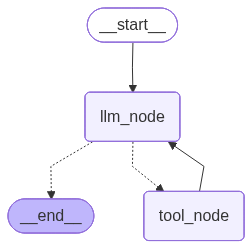

In [28]:
from langgraph.graph import StateGraph, START

builder = StateGraph(MessagesState)          # <- our state is MessagesState
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)

builder.add_edge(START, "llm_node")
builder.add_conditional_edges(               # branch after the LLM node
    "llm_node",
    should_continue,
    ["tool_node", END],                      # the possible destinations
)
builder.add_edge("tool_node", "llm_node")    # <- the agent loop

agent = builder.compile()
show(agent)

## 8 · Run it

**8a - a simple one-tool question.** Watch the conversation grow: Human -> AI(tool_call) -> Tool -> AI(answer).

In [31]:
result = agent.invoke({"messages": [HumanMessage("What is 7 plus 5, and what 6+3?")]})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 7 plus 5, and what 6+3?
================================== Ai Message ==================================
Tool Calls:
  add (call_UjH0Nglt9FKV8RWrlPPsfdfc)
 Call ID: call_UjH0Nglt9FKV8RWrlPPsfdfc
  Args:
    a: 7
    b: 5
  add (call_slCwKzi0oGjkEp5HzoPKnEJD)
 Call ID: call_slCwKzi0oGjkEp5HzoPKnEJD
  Args:
    a: 6
    b: 3
================================= Tool Message =================================

12
================================= Tool Message =================================

9
================================== Ai Message ==================================

7 plus 5 is 12, and 6 plus 3 is 9.


**8b - a multi-step question.** "Add 3 and 4, then multiply by 5." The model must call `add`, see
the result, then call `multiply`. The loop runs twice. Notice how it chains tool calls on its own:

In [32]:
result = agent.invoke({"messages": [HumanMessage("Add 3 and 4, then multiply the result by 5.")]})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4, then multiply the result by 5.
================================== Ai Message ==================================
Tool Calls:
  add (call_KfMtLzUfL4wry7XTgEbe8UMU)
 Call ID: call_KfMtLzUfL4wry7XTgEbe8UMU
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================
Tool Calls:
  multiply (call_IkIKyE3V91r4hGGDm8QFTU0W)
 Call ID: call_IkIKyE3V91r4hGGDm8QFTU0W
  Args:
    a: 7
    b: 5
================================= Tool Message =================================

35
================================== Ai Message ==================================

The result of adding 3 and 4 is 7, and when you multiply that by 5, you get 35.


Trace the loop in that output:
`Human` -> `AI` wants `add(3,4)` -> `Tool` returns 7 -> back to LLM -> `AI` wants `multiply(7,5)` ->
`Tool` returns 35 -> back to LLM -> `AI` gives the final answer (no tool_calls) -> END.

## 9 · You don't have to write the tool node - `ToolNode`

That `tool_node` we wrote (look up the tool, run it, wrap a `ToolMessage` with the right id, handle
several calls) is **identical in every agent**. So LangGraph ships it prebuilt as **`ToolNode`**. It
also handles parallel tool calls and tool errors for you.

Swap our hand-written node for `ToolNode(tools)` - **everything else stays exactly the same**:

In [33]:
from langgraph.prebuilt import ToolNode

builder2 = StateGraph(MessagesState)
builder2.add_node("llm_node", llm_node)
builder2.add_node("tool_node", ToolNode(tools))      # <- the only change
builder2.add_edge(START, "llm_node")
builder2.add_conditional_edges("llm_node", should_continue, ["tool_node", END])
builder2.add_edge("tool_node", "llm_node")

agent2 = builder2.compile()
result = agent2.invoke({"messages": [HumanMessage("What is (12 divided by 4) plus 10?")]})
print(result["messages"][-1].content)

The result of (12 divided by 4) plus 10 is 13.


LangGraph even ships the **routing** prebuilt too, as `tools_condition` - the same "tool_calls? ->
tools : END" logic we wrote in `should_continue`. So a from-scratch agent shrinks to a handful of lines.

## 10 · ...and the whole agent in one line - `create_agent`

The `llm_node <-> tool_node` loop with a router is *so* standard that LangChain wraps the entire thing
in **`create_agent`**. It builds the very same graph we just built by hand (its nodes are named
`model` and `tools`).

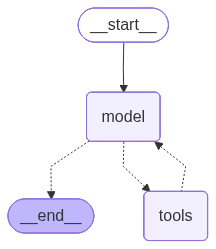

In [34]:
from langchain.agents import create_agent

quick_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=tools,
    system_prompt=SYSTEM,
)
show(quick_agent)

In [35]:
# same node-and-loop structure, just prebuilt:
print("our agent  :", list(agent.get_graph().nodes))
print("create_agent:", list(quick_agent.get_graph().nodes))

out = quick_agent.invoke({"messages": [HumanMessage("Add 10 and 5, then divide by 3.")]})
print("\nanswer:", out["messages"][-1].content)

our agent  : ['__start__', 'llm_node', 'tool_node', '__end__']
create_agent: ['__start__', 'model', 'tools', '__end__']

answer: The result of adding 10 and 5 is 15. When you divide 15 by 3, the result is 5.0.


## Recap

We built a ReAct agent from nothing:

| piece | what it does |
|---|---|
| **`MessagesState`** | the state: a list of messages with the `add_messages` (append) reducer |
| **`llm_node`** (Reason) | calls the tool-bound model; may return `tool_calls` |
| **`tool_node`** (Act) | runs the requested tools, returns `ToolMessage`s tagged by `tool_call_id` |
| **`should_continue`** | conditional edge: tool_calls? -> tools, else END |
| **`tool_node -> llm_node`** | the back-edge that makes it loop (an agent, not a workflow) |
| **`ToolNode`** | the prebuilt tool node - don't write it yourself |
| **`create_agent`** | the whole graph in one line |

Next we'll give this agent **real tools** (weather, flights, hotels) in the travel-agent project.

### 🏋️ Exercises
1. Add a `subtract` tool and ask a question that chains all four operations.
2. Print `should_continue`'s decision each step to watch the routing live.
3. Replace `tool_node` with `ToolNode` *and* the router with `tools_condition` from
   `langgraph.prebuilt` - how few lines does the agent become?